# Scikit-Learn Neural Nets Exercise

In [1]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X, y = make_regression(n_samples=1000, random_state=101)

In [3]:
# Split the training set into a training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=101)

In [4]:
pipe = Pipeline([('scaler', StandardScaler()), 
                 ('model', MLPRegressor(max_iter=500))])

In [5]:
parameters = {'model__hidden_layer_sizes':((20,), (10, 10), (7,7,7)), 'model__solver' : ['lbfgs', 'adam']}

In [6]:
# create an instance of MLPRegressor
estimator = GridSearchCV(pipe, parameters)

In [7]:
estimator.fit(X_train, y_train)

/home/janusz/Desktop/udemy data science/Machine Learning/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/janusz/Desktop/udemy data science/Machine Learning/venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  sel

,estimator,Pipeline(step...x_iter=500))])
,param_grid,"{'model__hidden_layer_sizes': ((20,), ...), 'model__solver': ['lbfgs', 'adam']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [8]:
estimator.cv_results_['mean_test_score']

array([0.99564111, 0.66454189, 0.99912523, 0.90397448, 0.99867957,
       0.83409976])

In [9]:
estimator.cv_results_['std_test_score']

array([0.00268371, 0.03480884, 0.0004752 , 0.00992253, 0.00133441,
       0.18256473])

In [10]:
estimator.best_params_

{'model__hidden_layer_sizes': (10, 10), 'model__solver': 'lbfgs'}

In [11]:
# Make Predictions
predictions = estimator.predict(X_test)

In [12]:
# Display the metrics
mean_absolute_error(y_test, predictions)

1.5258879328168518

Happy Learning!

In [13]:
mean_squared_error(y_test, predictions)

19.53863379690981

In [14]:
root_mean_squared_error(y_test, predictions)

4.4202526847353205

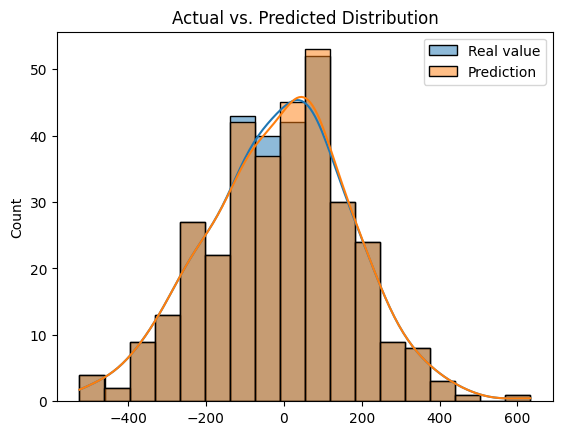

In [15]:
fig, ax = plt.subplots()
sns.histplot(y_test, ax = ax, label='Real value', kde=True, alpha=0.5)
sns.histplot(predictions, ax = ax, label='Prediction', kde=True, alpha=0.5)
ax.set_title('Actual vs. Predicted Distribution')
ax.legend()

Text(0.5, 1.0, 'Residuals Distribution Plot')

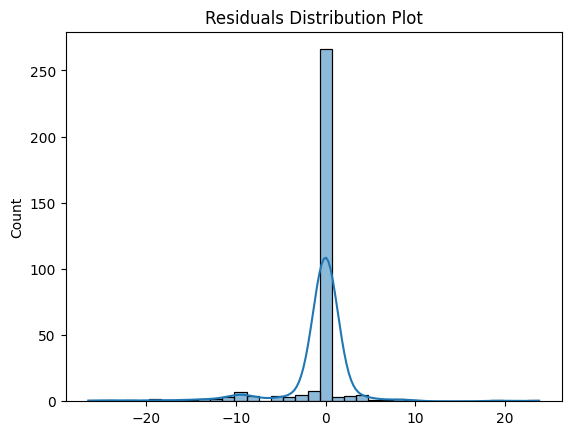

In [16]:
g = sns.histplot(y_test - predictions, kde=True)
g.set_title('Residuals Distribution Plot')